In [41]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


In [17]:
h_target = 110000 

lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


print(full_yknf_lat110.shape)

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_proj, yknf_lon_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_proj, fsmi_lon_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


(480, 553)


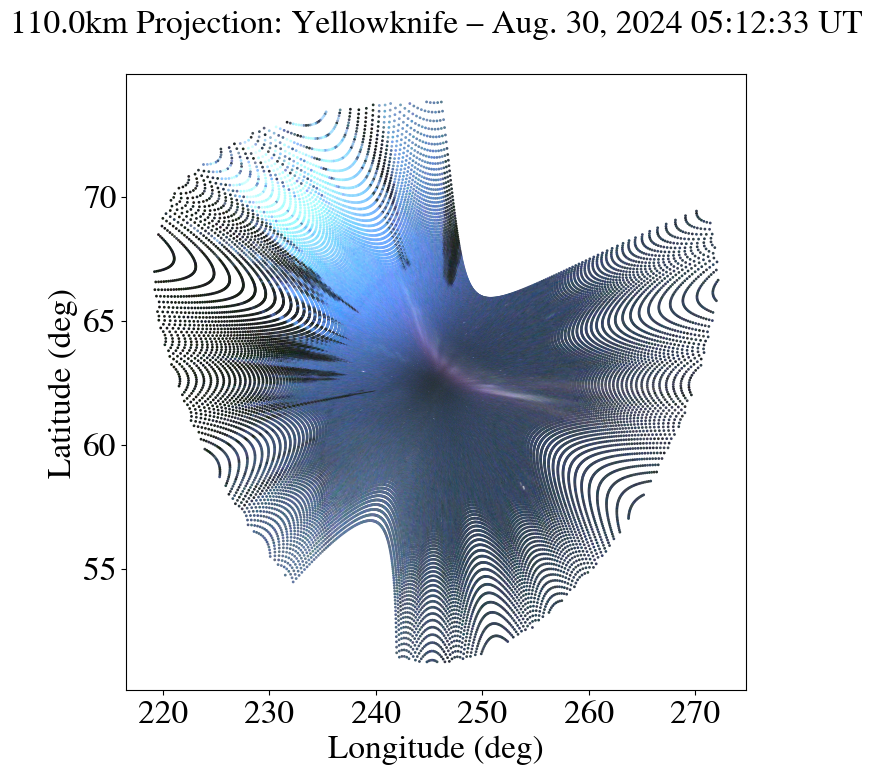

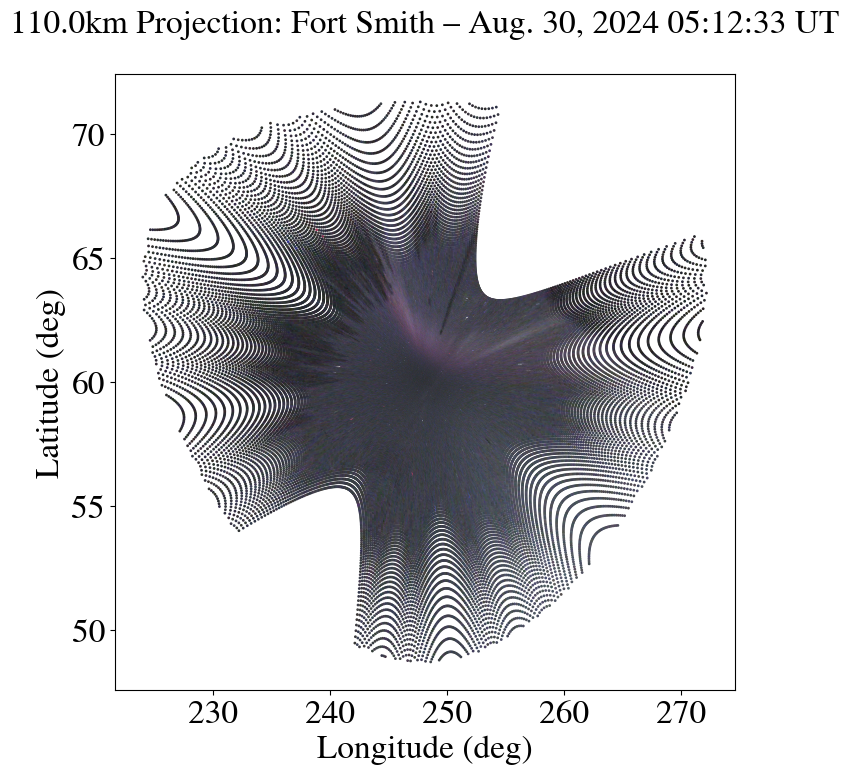

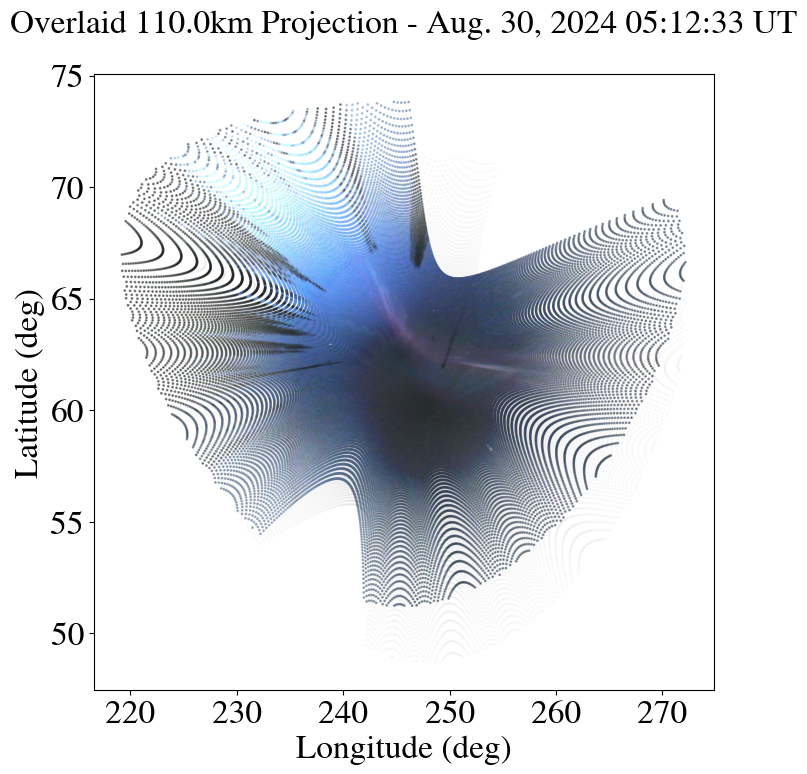

In [18]:
time_index = 251 # 5:10 UTC
site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

yknf_rgb, fsmi_rgb = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_proj, 
                                 yknf_lon_proj, 
                                 fsmi_lat_proj, 
                                 fsmi_lon_proj,
                                 h_target)

## Linear Fitting
1. taking vertical slices in longitude for each of the regions in the YKNF and in the FSMI frames (getting spectral lines), fit gaussians to the brightness of each pixel in the slice
   - the peak of the gaussian is the brightest pixel in the vertical slice is, record the lat and lon that that pixel occurs at
   - repeat this for all the slices across YKNF and FSMI frames, then fit a line to all of these recorded (lat, lon) of brightest pixels
   - calculate how different the lines are in slope and in vetical distance from eachother
   - this works bc theoretically, STEVE should be a straight phenomenon, hence fitting a straight line to it

2. Steps
    - pick out individuals columns --> this is done by interpolating to a line (fixed longitude, varying latitude) from the masked pixels to get each gaussian fit
      - can do this for every single column, or every 3 columns, etc
      - have an 480x553 array of all of the intensities, but also need the corresponding latitude and longitude values 
    - use scipy.optimize.curve_fit to fit gaussian function (x-values = latitude, y-values = pixel intensities)
    - find the coordinates (lat, lon) of the peak of each gaussian, store in some array
    - fit a line through the coordinates of all of the peaks
    - repeat for for both yknf and fsmi, and calculate the difference / distance between their respective lines (ie in slope and in vertical distance)

## REVISED METHOD
1. interpolate to a line over constant longitude
    - can do on RGB image? or do independently on each R, G, B channel 
3. should be getting many peaks, ok if there are some clouds and stuff, but the major peak is hopefully where the aurora is
4. loop over all of these different interpolations, fitting a gaussian to each one; find the peak of each gaussian and fit a line to each one of YKNF and FSMI frames
5. see how well they line up
6. repeat for many time steps 


heights to do for:
[100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000]

In [19]:
# # do on r, g, b channels independently
# # interpolate to 1 line varying lat, single lon

# def line_interpolate(lat_proj, lon_proj, rgb, 
#                      lat_min, lat_max, lon_min, lon_max,
#                      lat_min_box, lat_max_box):

#     """
#     input:
#         lat_proj = 2D projected latitude arr (output of project_lat_lon())
#         lon_proj = 2D projected longitude arr (output of project_lat_lon())
#         rgb = 3D rgb array (output of plot_lat_lon()) 
#         lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
#         lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
#         lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
#         lon_max = maximum longitude to create grid for (should be common between the 2 cameras)
#         lat_min_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
#         lat_max_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary

#     output:
#         R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
#     """
    
#     lat_arr = np.arange(lat_min, lat_max, 0.5)
#     lon_arr = np.arange(lon_min, lon_max, 1) # 1 slice in longitude every 1 degree 

#     print(f"Total {len(lon_arr)} longitudes to interpolate\n")
#     #lon_arr = [250]
#     R_peak_lat_arr = []
#     G_peak_lat_arr = []
#     B_peak_lat_arr = []

#     # longitudes that have a peak latitude that we are saving (to handle the masking we do on the latitude ranges)
#     R_lon_arr = []
#     G_lon_arr = []
#     B_lon_arr = []

#     R_gaussian_results = []
#     G_gaussian_results = []
#     B_gaussian_results = []

#     # separate into R, G, B channels
#     R = rgb[:,:, 0]
#     G = rgb[:,:, 1]
#     B = rgb[:,:, 2]
    
#     # flatten yknf and fsmi projected arrays + R + G + B arrays 
#     flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
#     flattened_R = R.flatten()
#     flattened_G = G.flatten()
#     flattened_B = B.flatten()
        
#     # remove NaNs
#     # masks for NaNs in R, G, and B channels separately 
#     nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
#     nan_mask_G = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_G))
#     nan_mask_B = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_B))
    
#     points_R_clean = flattened_points[nan_mask_R]
#     points_G_clean = flattened_points[nan_mask_G]
#     points_B_clean = flattened_points[nan_mask_B]
    
#     values_R_clean = flattened_R[nan_mask_R]
#     values_G_clean = flattened_G[nan_mask_G]
#     values_B_clean = flattened_B[nan_mask_B]

#     for idx, single_lon in enumerate(lon_arr):
#         print(f"{idx}-- Longitude Interpolating: {single_lon}")
#         single_lon_arr = single_lon * np.ones(np.shape(lat_arr)) # constant latitude, as many as there are latitudes to interpolate over 
#         interp_locations = np.column_stack((single_lon_arr, lat_arr)) # array of (lon, lat) x-y pairs, longitude is constant so get line in lat

#         R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear')
#         G_intensity_profile = griddata(points_G_clean, values_G_clean, interp_locations, method='linear')
#         B_intensity_profile = griddata(points_B_clean, values_B_clean, interp_locations, method='linear')

#         # plt.figure(figsize=(8,5))
#         # plt.plot(lat_arr, R_intensity_profile, 'r-', label='R channel')
#         # plt.plot(lat_arr, G_intensity_profile, 'g-', label='G channel')
#         # plt.plot(lat_arr, B_intensity_profile, 'b-', label='B channel')
        
#         # plt.xlabel('Latitude')
#         # plt.ylabel('Interpolated Intensity')
#         # plt.title(f'Interpolated RGB intensity profile at lon = {single_lon}')
#         # plt.legend()
#         # plt.grid(True)
#         # plt.show()
#         # plt.close() # memory!! 

#         # restrict the latitude to likely latitudes for the aurora (so gaussian can be fit)
#         # NOT robust for different time stamps 
#         # also remove NaNs so curve_fit will work (NaNs added if points to be interpolated outside of convex hull)
#         lat_mask = (lat_arr >= lat_min_box) & (lat_arr <= lat_max_box)
#         R_nan_mask = np.isfinite(R_intensity_profile)
#         G_nan_mask = np.isfinite(G_intensity_profile)
#         B_nan_mask = np.isfinite(B_intensity_profile)

#         R_intensity_restricted = R_intensity_profile[lat_mask & R_nan_mask]
#         G_intensity_restricted = G_intensity_profile[lat_mask & G_nan_mask]
#         B_intensity_restricted = B_intensity_profile[lat_mask & B_nan_mask]
#         lat_arr_restricted = lat_arr[lat_mask] 

#         if R_intensity_restricted.size==0 or G_intensity_restricted.size==0 or B_intensity_restricted.size==0:
#             print("No points in this latitude range for this longitude slice.\n")
#             continue  # or handle appropriately
        
#         # # parameters for gaussian 
#         # A0_R = np.max(R_intensity_restricted) - np.min(R_intensity_restricted) #amplitude
#         # mu0_R = lat_arr_restricted[np.argmax(R_intensity_restricted)] #mean/center
#         # sigma0_R = 0.5 #std/width
#         # C0_R = np.min(R_intensity_restricted) #baseline intensity / offset

#         # A0_G = np.max(G_intensity_restricted) - np.min(G_intensity_restricted)
#         # mu0_G = lat_arr_restricted[np.argmax(G_intensity_restricted)]
#         # sigma0_G = 0.5
#         # C0_G = np.min(G_intensity_restricted)

#         # A0_B = np.max(B_intensity_restricted) - np.min(B_intensity_restricted)
#         # mu0_B = lat_arr_restricted[np.argmax(B_intensity_restricted)]
#         # sigma0_B = 0.5
#         # C0_B = np.min(B_intensity_restricted)
    
#         # # fit gaussian, except when there are nan values 
#         # try:
#         #     R_opt_params, _ = curve_fit(gaussian, lat_arr_restricted, R_intensity_restricted, p0=[A0_R, mu0_R, sigma0_R, C0_R])
#         #     G_opt_params, _ = curve_fit(gaussian, lat_arr_restricted, G_intensity_restricted, p0=[A0_G, mu0_G, sigma0_G, C0_G])
#         #     B_opt_params, _ = curve_fit(gaussian, lat_arr_restricted, B_intensity_restricted, p0=[A0_B, mu0_B, sigma0_B, C0_B])
            
#         #     R_gaussian_results.append((single_lon, *R_opt_params))
#         #     G_gaussian_results.append((single_lon, *G_opt_params))
#         #     B_gaussian_results.append((single_lon, *B_opt_params))
#         # except:
#         #     R_gaussian_results.append((single_lon, np.nan, np.nan, np.nan, np.nan)) # in case parameters weren't found (couldn't fit gaussian)
#         #     G_gaussian_results.append((single_lon, np.nan, np.nan, np.nan, np.nan)) 
#         #     B_gaussian_results.append((single_lon, np.nan, np.nan, np.nan, np.nan))

#         # print("Attempted gaussian fit params R G B")
#         # print(R_gaussian_results[0])
#         # print(G_gaussian_results[0])
#         # print(B_gaussian_results[0])

#         # jsut pick out the maximum intensity from the expected range of latitudes
#         # indices for intensity & latitude should correspond 
#         # make another array for the corresponding longitudes to the peak latitude (accounts for when hitting the exception intensity_restricted.size=0)
#         idx_peak_R = np.argmax(R_intensity_restricted)
#         R_peak_lat_arr.append(lat_arr_restricted[idx_peak_R])
#         R_lon_arr.append(single_lon)

#         idx_peak_G = np.argmax(G_intensity_restricted)
#         G_peak_lat_arr.append(lat_arr_restricted[idx_peak_G])
#         G_lon_arr.append(single_lon)

#         idx_peak_B = np.argmax(B_intensity_restricted)
#         B_peak_lat_arr.append(lat_arr_restricted[idx_peak_B])
#         B_lon_arr.append(single_lon)


#         # print("\nPeak intensities R G B")
#         # print(R_peak_lat_arr[0])
#         # print(G_peak_lat_arr[0])
#         # print(B_peak_lat_arr[0])

#         # return R_peak_lat_arr, G_peak_lat_arr, B_peak_lat_arr, lon_arr

#         ## plot the (lon, lat_peak) pairs as a fit line overlaid on the aurora
#         # fit line to points --> probs need to remove outliers
#         # R_slope, R_intercept = np.polyfit(lon_arr, R_peak_lat_arr, 1)
#         # G_slope, G_intercept = np.polyfit(lon_arr, G_peak_lat_arr, 1)
#         # B_slope, B_intercept = np.polyfit(lon_arr, B_peak_lat_arr, 1)

#     # plt.figure(figsize=(10,8))
#     # plt.imshow(np.clip(rgb, 0, 1), 
#     #            origin='lower',
#     #            extent=[lon_min, lon_max, lat_min, lat_max])
#     # plt.xlabel('Longitude')
#     # plt.ylabel('Latitude')
#     # plt.title('Aurora with Fitted Lines')

#     plt.figure(figsize=(10,8))
#     plt.scatter(lon_proj.flatten(),lat_proj.flatten(),c=rgb.reshape(-1, 3)/256,s=1)
#     plt.ylabel("Latitude (deg)")
#     plt.xlabel("Longitude (deg)")
#     plt.title(f"Aurora with Fitted Lines")
    
#     # plot the peak points for R, G, B
#     plt.scatter(R_lon_arr, R_peak_lat_arr, color='red', label='Peak R intensity', s=50)
#     plt.scatter(G_lon_arr, G_peak_lat_arr, color='green', label='Peak G intensity', s=50)
#     plt.scatter(B_lon_arr, B_peak_lat_arr, color='blue', label='Peak B intensity', s=50)
    
#     # Overlay the fitted line
#     # lon_line = np.linspace(min(lon_arr), max(lon_arr), 100)
#     # R_lat_line = R_slope * lon_line + R_intercept
#     # G_lat_line = G_slope * lon_line + G_intercept
#     # B_lat_line = B_slope * lon_line + B_intercept

#     # plt.plot(lon_line, R_lat_line, 'red', linewidth=2, label='R fitted line')
#     # plt.plot(lon_line, G_lat_line, 'green', linewidth=2, label='G fitted line')
#     # plt.plot(lon_line, B_lat_line, 'blue', linewidth=2, label='B fitted line')

#     plt.legend()
#     plt.show()

#     print(f"r peak lat arr len: {len(R_peak_lat_arr)}")
#     print(f"R_lon_arr len: {len(R_lon_arr)}")
#     return R_peak_lat_arr, G_peak_lat_arr, B_peak_lat_arr, R_lon_arr









In [59]:
# do on r, g, b channels independently
# interpolate to 1 line varying lat, single lon

def line_interpolate(lat_proj, lon_proj, rgb, 
                     lat_min, lat_max, lon_min, lon_max,
                     lat_min_box, lat_max_box, 
                     lon_min_box, lon_max_box,
                     site_name, folder_name, altitude):

    """
    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of plot_lat_lon()) 
        lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
        lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
        lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
        lon_max = maximum longitude to create grid for (should be common between the 2 cameras)
        lat_min_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
        lat_max_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
        lon_min_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
        lon_max_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)

    output:
        R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
    """
    
    lat_arr = np.arange(lat_min, lat_max, 0.5)
    lon_arr = np.arange(lon_min, lon_max, 1) # 1 slice in longitude every 1 degree 
    #lon_arr = [250, 251]


    print(f"Total {len(lon_arr)} longitudes to interpolate\n")
    R_peak_lat_arr = []
    G_peak_lat_arr = []
    B_peak_lat_arr = []

    # longitudes that have a peak latitude that we are saving (to handle the masking we do on the latitude ranges)
    R_lon_arr = []
    G_lon_arr = []
    B_lon_arr = []

    R_gaussian_results = []
    G_gaussian_results = []
    B_gaussian_results = []

    # separate into R, G, B channels
    R = rgb[:,:, 0]
    G = rgb[:,:, 1]
    B = rgb[:,:, 2]
    
    # flatten yknf and fsmi projected arrays + R + G + B arrays 
    flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
    flattened_R = R.flatten()
    flattened_G = G.flatten()
    flattened_B = B.flatten()
        
    # remove NaNs
    # masks for NaNs in R, G, and B channels separately 
    nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
    nan_mask_G = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_G))
    nan_mask_B = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_B))
    
    points_R_clean = flattened_points[nan_mask_R]
    points_G_clean = flattened_points[nan_mask_G]
    points_B_clean = flattened_points[nan_mask_B]
    
    values_R_clean = flattened_R[nan_mask_R]
    values_G_clean = flattened_G[nan_mask_G]
    values_B_clean = flattened_B[nan_mask_B]

    for idx, single_lon in enumerate(lon_arr):
        print(f"{idx}-- Longitude Interpolating: {single_lon}")
        single_lon_arr = single_lon * np.ones(np.shape(lat_arr)) # constant latitude, as many as there are latitudes to interpolate over 
        interp_locations = np.column_stack((single_lon_arr, lat_arr)) # array of (lon, lat) x-y pairs, longitude is constant so get line in lat

        R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear')
        G_intensity_profile = griddata(points_G_clean, values_G_clean, interp_locations, method='linear')
        B_intensity_profile = griddata(points_B_clean, values_B_clean, interp_locations, method='linear')


        # intensity profile plots 
        plt.figure(figsize=(8,5))
        plt.plot(lat_arr, R_intensity_profile, 'r-', label='R channel')
        plt.plot(lat_arr, G_intensity_profile, 'g-', label='G channel')
        plt.plot(lat_arr, B_intensity_profile, 'b-', label='B channel')

        plt.xlabel('Latitude')
        plt.ylabel('Interpolated Intensity')
        plt.title(f'{altitude/1000.0}km Interpolated RGB intensity profile at lon = {single_lon:.2f}')
        plt.legend()
        plt.grid(True)

        os.makedirs(folder_name, exist_ok=True)
        output_path = os.path.join(folder_name, f"{site_name}_rgb_profile_alt{altitude/1000.0}_lon{single_lon:.2f}.png")
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close() # memory!! 
        
        # restrict the latitude to likely latitudes for the aurora (so gaussian can be fit)
        # NOT robust for different time stamps 
        # also remove NaNs so curve_fit will work (NaNs added if points to be interpolated outside of convex hull)
        lat_mask = (lat_arr >= lat_min_box) & (lat_arr <= lat_max_box)
        R_nan_mask = np.isfinite(R_intensity_profile)
        G_nan_mask = np.isfinite(G_intensity_profile)
        B_nan_mask = np.isfinite(B_intensity_profile)

        R_intensity_restricted = R_intensity_profile[lat_mask & R_nan_mask]
        G_intensity_restricted = G_intensity_profile[lat_mask & G_nan_mask]
        B_intensity_restricted = B_intensity_profile[lat_mask & B_nan_mask]
        lat_arr_restricted = lat_arr[lat_mask] 

        if R_intensity_restricted.size==0 or G_intensity_restricted.size==0 or B_intensity_restricted.size==0:
            print("No points in this latitude range for this longitude slice.\n")
            continue  
        
        # jsut pick out the maximum intensity from the expected range of latitudes
        # indices for intensity & latitude should correspond 
        # make another array for the corresponding longitudes to the peak latitude (accounts for when hitting the exception intensity_restricted.size=0)
        # restrict the longitude so don't get meaningless peak intensities 
        if single_lon <= lon_max_box and single_lon >= lon_min_box:
            idx_peak_R = np.argmax(R_intensity_restricted)
            R_peak_lat_arr.append(lat_arr_restricted[idx_peak_R])
            R_lon_arr.append(single_lon)
    
            idx_peak_G = np.argmax(G_intensity_restricted)
            G_peak_lat_arr.append(lat_arr_restricted[idx_peak_G])
            G_lon_arr.append(single_lon)
    
            idx_peak_B = np.argmax(B_intensity_restricted)
            B_peak_lat_arr.append(lat_arr_restricted[idx_peak_B])
            B_lon_arr.append(single_lon)

    # remove outliers in peak latitude before line fitting
    # need to convert to np arrays
    R_peak_lat_arr = np.asarray(R_peak_lat_arr)
    G_peak_lat_arr = np.asarray(G_peak_lat_arr)
    B_peak_lat_arr = np.asarray(B_peak_lat_arr)
    R_lon_arr = np.asarray(R_lon_arr)
    G_lon_arr = np.asarray(G_lon_arr)
    B_lon_arr = np.asarray(B_lon_arr)


    Q1 = np.quantile(R_peak_lat_arr, 0.25)
    Q3 = np.quantile(R_peak_lat_arr, 0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # filter mask --> remove outlying 
    peak_lat_mask = (R_peak_lat_arr >= lower_bound) & (R_peak_lat_arr < upper_bound)
    R_peak_lat_arr_filtered = R_peak_lat_arr[peak_lat_mask]
    R_lon_arr_filtered = R_lon_arr[peak_lat_mask]

    print(R_lon_arr_filtered)
    print(R_peak_lat_arr_filtered)

    Q1 = np.quantile(G_peak_lat_arr, 0.25)
    Q3 = np.quantile(G_peak_lat_arr, 0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # filter mask --> remove outlying 
    peak_lat_mask = (G_peak_lat_arr >= lower_bound) & (G_peak_lat_arr < upper_bound)
    G_peak_lat_arr_filtered = G_peak_lat_arr[peak_lat_mask]
    G_lon_arr_filtered = G_lon_arr[peak_lat_mask]

    Q1 = np.quantile(B_peak_lat_arr, 0.25)
    Q3 = np.quantile(B_peak_lat_arr, 0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # filter mask --> remove outlying 
    peak_lat_mask = (B_peak_lat_arr >= lower_bound) & (B_peak_lat_arr < upper_bound)
    B_peak_lat_arr_filtered = B_peak_lat_arr[peak_lat_mask]
    B_lon_arr_filtered = B_lon_arr[peak_lat_mask]


    # plot aurora image
    plt.figure(figsize=(10,8))
    plt.scatter(lon_proj.flatten(),lat_proj.flatten(),c=rgb.reshape(-1, 3)/256,s=1)
    plt.ylabel("Latitude (deg)")
    plt.xlabel("Longitude (deg)")
    plt.title(f"Aurora with Fitted Lines")

    # plot the (lon, lat_peak) pairs as a fit line overlaid on the aurora
    # fit line to points --> probs need to remove outliers?
    R_slope, R_intercept = np.polyfit(R_lon_arr_filtered, R_peak_lat_arr_filtered, 1)
    G_slope, G_intercept = np.polyfit(G_lon_arr_filtered, G_peak_lat_arr_filtered, 1)
    B_slope, B_intercept = np.polyfit(B_lon_arr_filtered, B_peak_lat_arr_filtered, 1)
    
    # plot the peak points for R, G, B (raw)
    plt.scatter(R_lon_arr, R_peak_lat_arr, color='red', label='Peak R', s=30)
    plt.scatter(G_lon_arr, G_peak_lat_arr, color='green', label='Peak G', s=30)
    plt.scatter(B_lon_arr, B_peak_lat_arr, color='blue', label='Peak B', s=30)

    # plot the peak points for R, G, B (outliers removed)
    plt.scatter(R_lon_arr_filtered, R_peak_lat_arr_filtered, color='pink', label='Peak R (f)', s=30)
    plt.scatter(G_lon_arr_filtered, G_peak_lat_arr_filtered, color='palegreen', label='Peak G (f)', s=30)
    plt.scatter(B_lon_arr_filtered, B_peak_lat_arr_filtered, color='xkcd:periwinkle', label='Peak B (f)', s=30)

    # overlay the fitted lines
    lon_line = np.linspace(min(lon_arr), max(lon_arr), 100) # so line extends fully, dont just use filtered lons
    #lon_line = np.linspace(min(R_lon_arr_filtered), max(R_lon_arr_filtered), 100) # should be about the same for all 3 RGB, so just use R for domain restriction
    R_lat_line = R_slope * lon_line + R_intercept
    G_lat_line = G_slope * lon_line + G_intercept
    B_lat_line = B_slope * lon_line + B_intercept

    plt.plot(lon_line, R_lat_line, 'red', linewidth=2, label='R fitted line')
    plt.plot(lon_line, G_lat_line, 'green', linewidth=2, label='G fitted line')
    plt.plot(lon_line, B_lat_line, 'blue', linewidth=2, label='B fitted line')

    plt.legend(
        fontsize=8,        # smaller text
        markerscale=0.8,   # smaller marker icons
        handlelength=1,    # shorter legend lines
        handletextpad=0.4, # tighter text spacing
        borderpad=0.3      # smaller legend box padding
    )
    plt.show()

    print(f"r peak lat arr len: {len(R_peak_lat_arr)}")
    print(f"R_lon_arr len: {len(R_lon_arr)}")
    return (lon_line, R_lat_line, G_lat_line, B_lat_line, 
            R_slope, R_intercept, 
            G_slope, G_intercept, 
            B_slope, B_intercept,
            peak_lat_mask) # need peak lat mask so can restrict the lines of best fit to common domain for mean perpendicular dist calcs 


Total 53 longitudes to interpolate

0-- Longitude Interpolating: 219.20315924022748
No points in this latitude range for this longitude slice.

1-- Longitude Interpolating: 220.20315924022748
2-- Longitude Interpolating: 221.20315924022748
3-- Longitude Interpolating: 222.20315924022748
4-- Longitude Interpolating: 223.20315924022748
5-- Longitude Interpolating: 224.20315924022748
6-- Longitude Interpolating: 225.20315924022748
7-- Longitude Interpolating: 226.20315924022748
8-- Longitude Interpolating: 227.20315924022748
9-- Longitude Interpolating: 228.20315924022748
10-- Longitude Interpolating: 229.20315924022748
11-- Longitude Interpolating: 230.20315924022748
12-- Longitude Interpolating: 231.20315924022748
13-- Longitude Interpolating: 232.20315924022748
14-- Longitude Interpolating: 233.20315924022748
15-- Longitude Interpolating: 234.20315924022748
16-- Longitude Interpolating: 235.20315924022748
17-- Longitude Interpolating: 236.20315924022748
18-- Longitude Interpolating: 23

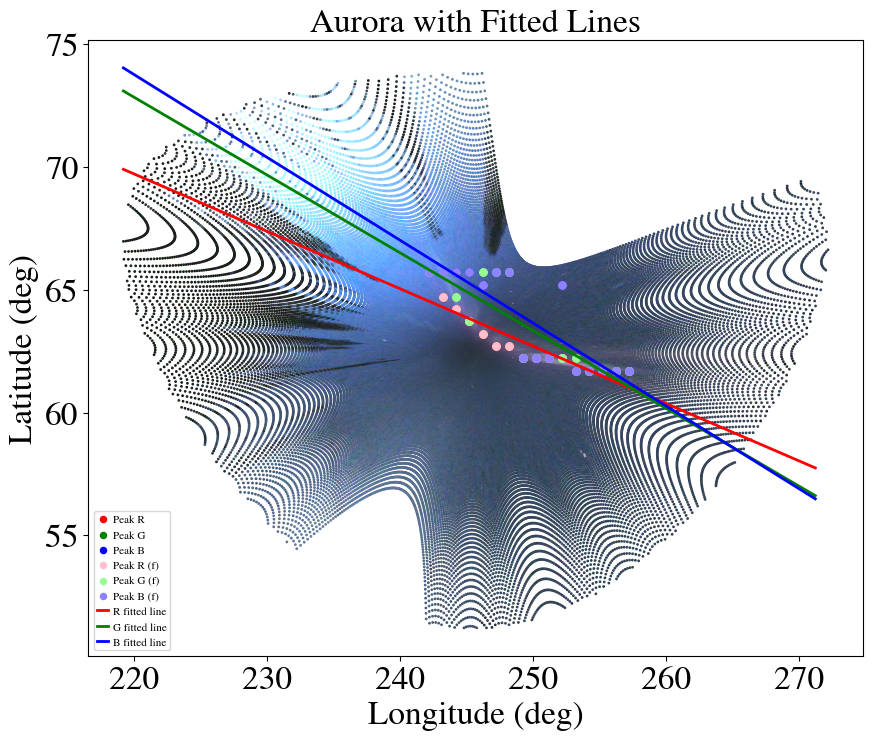

r peak lat arr len: 16
R_lon_arr len: 16


In [63]:
lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

### YKNF 

lat_min_box = 61
lat_max_box = 66
lon_min_box = 242
lon_max_box = 258
site_name = 'yknf'
folder_name = 'yknf_intensity_profiles'
yknf_lon_line, yknf_R_lat_line, yknf_G_lat_line, yknf_B_lat_line, yknf_R_slope, yknf_R_intercept, yknf_G_slope, yknf_G_intercept, yknf_B_slope, yknf_B_intercept, yknf_peak_lat_mask = line_interpolate(yknf_lat_proj, yknf_lon_proj, yknf_rgb, lat_min, lat_max, lon_min, lon_max, lat_min_box, lat_max_box, lon_min_box, lon_max_box, site_name, folder_name, h_target)

Total 53 longitudes to interpolate

0-- Longitude Interpolating: 219.20315924022748
No points in this latitude range for this longitude slice.

1-- Longitude Interpolating: 220.20315924022748
No points in this latitude range for this longitude slice.

2-- Longitude Interpolating: 221.20315924022748
No points in this latitude range for this longitude slice.

3-- Longitude Interpolating: 222.20315924022748
No points in this latitude range for this longitude slice.

4-- Longitude Interpolating: 223.20315924022748
No points in this latitude range for this longitude slice.

5-- Longitude Interpolating: 224.20315924022748
6-- Longitude Interpolating: 225.20315924022748
7-- Longitude Interpolating: 226.20315924022748
8-- Longitude Interpolating: 227.20315924022748
9-- Longitude Interpolating: 228.20315924022748
10-- Longitude Interpolating: 229.20315924022748
11-- Longitude Interpolating: 230.20315924022748
12-- Longitude Interpolating: 231.20315924022748
13-- Longitude Interpolating: 232.203

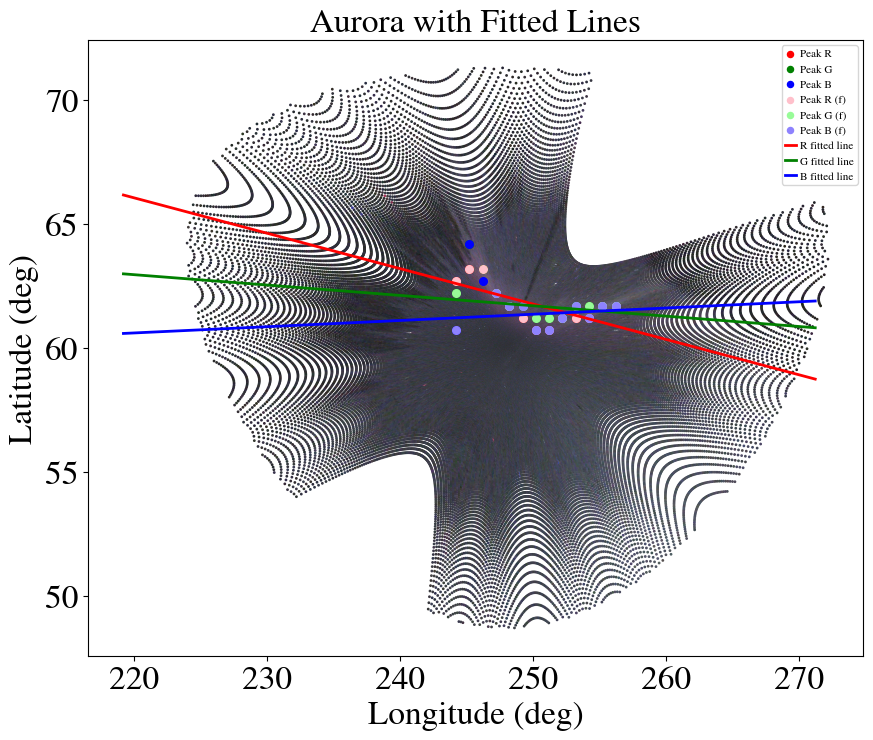

r peak lat arr len: 13
R_lon_arr len: 13


In [64]:
### FSMI 

lat_min_box = 60
lat_max_box = 65
lon_min_box = 244
lon_max_box = 257
site_name = 'fsmi'
folder_name = 'fsmi_intensity_profiles'
fsmi_lon_line, fsmi_R_lat_line, fsmi_G_lat_line, fsmi_B_lat_line, fsmi_R_slope, fsmi_R_intercept, fsmi_G_slope, fsmi_G_intercept, fsmi_B_slope, fsmi_B_intercept, fsmi_peak_lat_mask = line_interpolate(fsmi_lat_proj, fsmi_lon_proj, fsmi_rgb, lat_min, lat_max, lon_min, lon_max, lat_min_box, lat_max_box, lon_min_box, lon_max_box, site_name, folder_name, h_target)

R slope diff: 0.0909663865546233
R intercept diff: 23.66720399746714
R mean perpendicular distance: 23.66720399746714


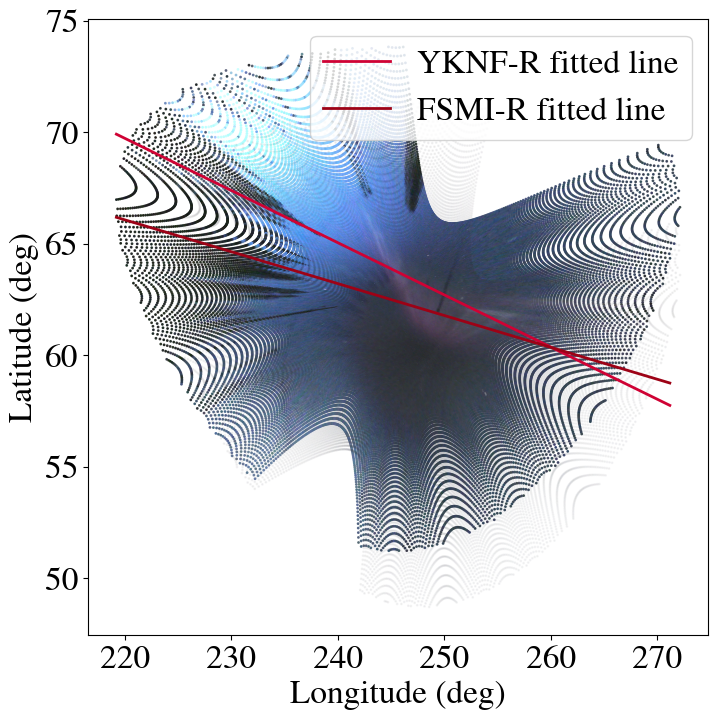

In [65]:
# overlaid
R_slope_diff = abs(yknf_R_slope - fsmi_R_slope)
R_intercept_diff = abs(yknf_R_intercept - fsmi_R_intercept)

# restrict the domains of the fsmi and yknf R lat lines, common domain so they are comparable 
lon_min_overlap = max(yknf_lon_line.min(), fsmi_lon_line.min())
lon_max_overlap = min(yknf_lon_line.max(), fsmi_lon_line.max())

lon_shared = np.linspace(lon_min_overlap, lon_max_overlap, 100)
yknf_R_lat_shared = yknf_R_slope * lon_shared + yknf_R_intercept
fsmi_R_lat_shared = fsmi_R_slope * lon_shared + fsmi_R_intercept

# restrict domain of line to where aurora is 
R_perp_dist = np.abs(fsmi_R_lat_shared - yknf_R_lat_shared) / np.sqrt((yknf_R_slope)**2+1)
R_perp_dist_mean = np.mean(R_perp_dist)

print(f"R slope diff: {R_slope_diff}")
print(f"R intercept diff: {R_intercept_diff}")
print(f"R mean perpendicular distance: {R_intercept_diff}")

plt.figure(figsize=(8,8))
plt.scatter(yknf_lon_proj.flatten(),yknf_lat_proj.flatten(),c=yknf_rgb.reshape(-1, 3)/256,s=1, alpha=0.9)
plt.scatter(fsmi_lon_proj.flatten(),fsmi_lat_proj.flatten(),c=fsmi_rgb.reshape(-1, 3)/256,s=1, alpha=0.05)

# before finding common lon domain 
# plt.plot(yknf_lon_line, yknf_R_lat_line, 'xkcd:cherry', linewidth=2, label='YKNF-R fitted line')
# plt.plot(fsmi_lon_line, fsmi_R_lat_line, 'xkcd:carmine', linewidth=2, label='FSMI-R fitted line')

plt.plot(lon_shared, yknf_R_lat_shared, 'xkcd:cherry', linewidth=2, label='YKNF-R fitted line')
plt.plot(lon_shared, fsmi_R_lat_shared, 'xkcd:carmine', linewidth=2, label='FSMI-R fitted line')

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")

plt.legend()
plt.show()

In [66]:
# {projected altitude : (slope difference, intercept difference, mean perp distance)}
alignment_dict[h_target/1000.0] = (R_slope_diff, R_intercept_diff, R_intercept_diff)

In [67]:
alignment_dict

{100.0: (0.06098901098900919, 16.28223856933937, 16.28223856933937),
 110.0: (0.0909663865546233, 23.66720399746714, 23.66720399746714)}